<a href="https://colab.research.google.com/github/Akulverma2/AIML-projects/blob/main/Animal_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
df = pd.read_csv("class.csv")
# PREPARE DATA (ADD CONTEXT)
rows = []
for i in range(len(df)):
    animals = df.loc[i, "Animal_Names"].split(",")
    for animal in animals:
        animal = animal.strip().lower()
        class_name = df.loc[i, "Class_Type"].lower()

        sentence = f"{animal} is a {class_name}"

        rows.append([sentence, class_name])

new_df = pd.DataFrame(rows, columns=["Text", "Class"])


In [73]:
# ENCODE LABELS
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(new_df["Class"])
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(new_df["Text"])

X = tokenizer.texts_to_sequences(new_df["Text"])

max_len = max(len(x) for x in X)
X = pad_sequences(X, maxlen=max_len, padding='post')

In [74]:
vocab_size = len(tokenizer.word_index) + 1

model = tf.keras.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=16),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(set(y)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(X, y, epochs=100, verbose=1)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4059 - loss: 1.9435
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4752 - loss: 1.9332
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4455 - loss: 1.9228
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4356 - loss: 1.9121
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4158 - loss: 1.9006
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4158 - loss: 1.8869
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4356 - loss: 1.8724
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4554 - loss: 1.8570
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5149 - loss: 1.8394
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5248 - loss: 1.8201
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5743 - loss: 1.7999
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5941 - lo

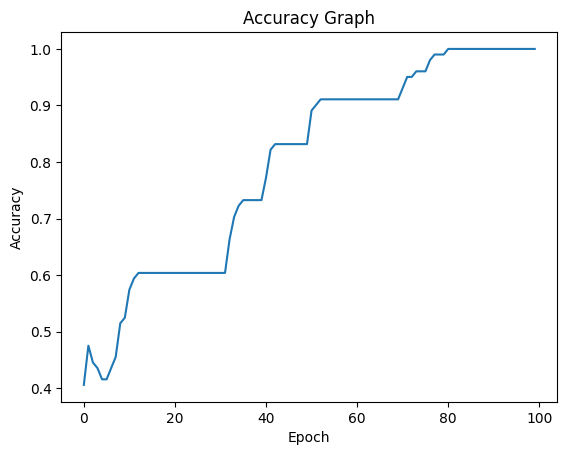

In [75]:
plt.plot(history.history['accuracy'])
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [76]:
def predict_animals(animal_list):
    # add same context as training
    sentences = [f"{a.lower()} is a ?" for a in animal_list]

    seq = tokenizer.texts_to_sequences(sentences)
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    prediction = model.predict(pad)
    pred_classes = prediction.argmax(axis=1)

    return le.inverse_transform(pred_classes)

In [81]:
animals = ["ostrich", "lion", "bear"]
results = predict_animals(animals)

for a, r in zip(animals, results):
    print(a, "→", r)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
ostrich → bird
lion → mammal
bear → mammal
